In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"C:\Users\Neel Arora\OneDrive\Desktop\Advanced Machine Learning\Advanced Machine Learning\Ensemble Model\Boosting\Gradient Approach Boosting\CAT Boost\Loan Default Prediction\loan_data.csv")
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [27]:
df.columns

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='object')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


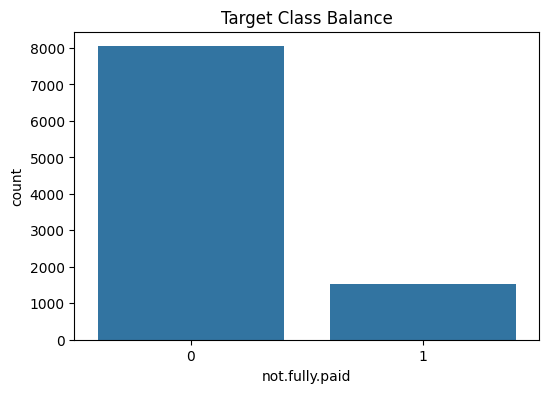

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x="not.fully.paid", data=df)
plt.title("Target Class Balance")
plt.show()

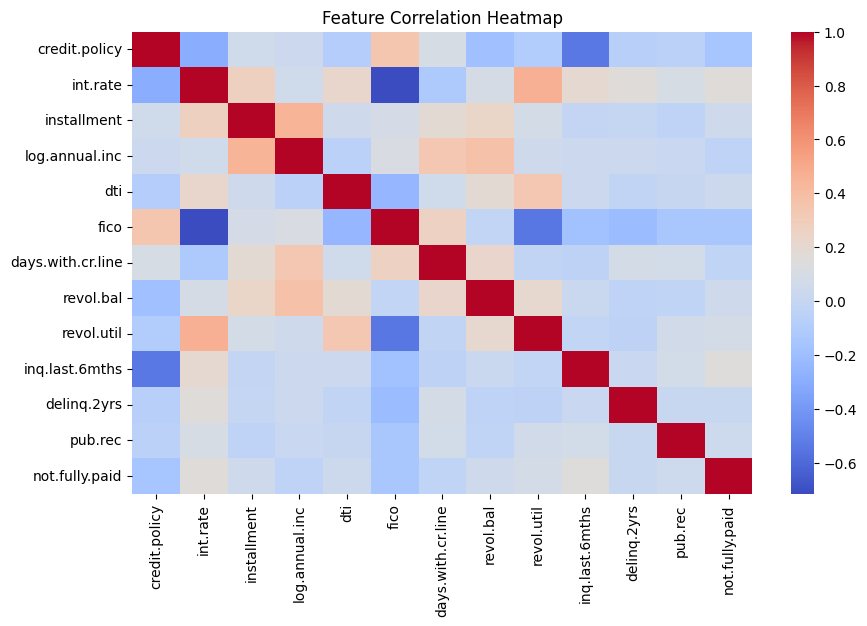

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes("number").corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [5]:
cat_features = ["purpose"]

In [6]:
X = df.drop("not.fully.paid", axis=1)
y = df["not.fully.paid"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    stratify=y,
    random_state=35
)

In [22]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric="AUC",
    class_weights=[1, 3],
    verbose=100,
    random_seed=42
)
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.6306581	best: 0.6306581 (0)	total: 40ms	remaining: 20s
100:	test: 0.7033573	best: 0.7033573 (100)	total: 2.69s	remaining: 10.6s
200:	test: 0.7110868	best: 0.7130435 (191)	total: 5.15s	remaining: 7.66s
300:	test: 0.7027808	best: 0.7130435 (191)	total: 7.65s	remaining: 5.05s
400:	test: 0.6955385	best: 0.7130435 (191)	total: 10.1s	remaining: 2.5s
499:	test: 0.6826696	best: 0.7130435 (191)	total: 12.6s	remaining: 0us

bestTest = 0.7130434783
bestIteration = 191

Shrink model to first 192 iterations.


In [23]:
y_proba = model.predict_proba(X_test)[:, 1]
threshold = 0.4
y_pred = (y_proba > threshold).astype(int)

In [24]:
auc = roc_auc_score(y_test, y_proba)
print("\n✅ Accuracy:", accuracy_score(y_test, y_pred))
print("✅ AUC Score:", auc)
print("\n✅ Classification Report:\n")
print(classification_report(y_test, y_pred))


✅ Accuracy: 0.7265135699373695
✅ AUC Score: 0.7130434782608696

✅ Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.77      0.83       805
           1       0.29      0.51      0.37       153

    accuracy                           0.73       958
   macro avg       0.59      0.64      0.60       958
weighted avg       0.80      0.73      0.75       958



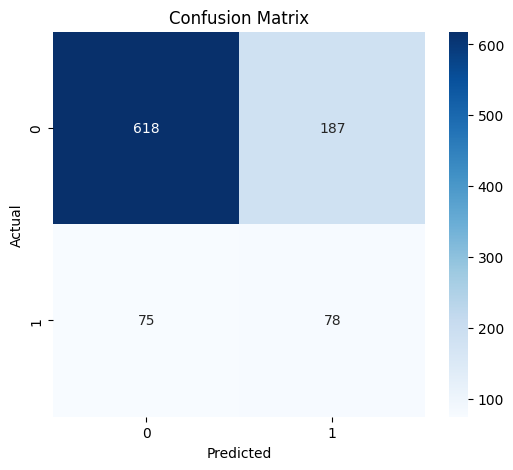

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

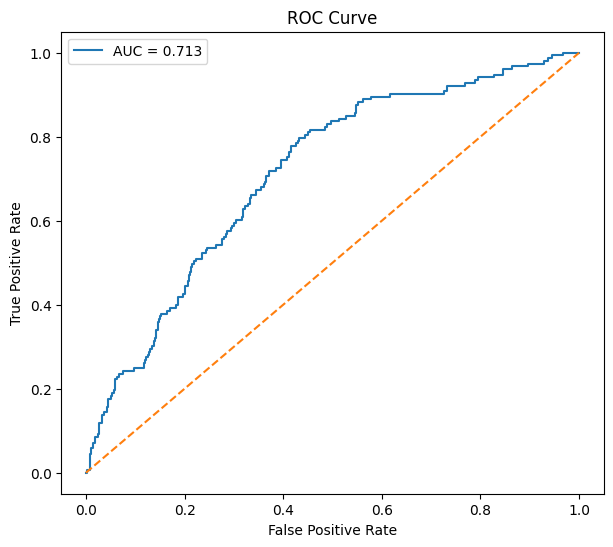

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

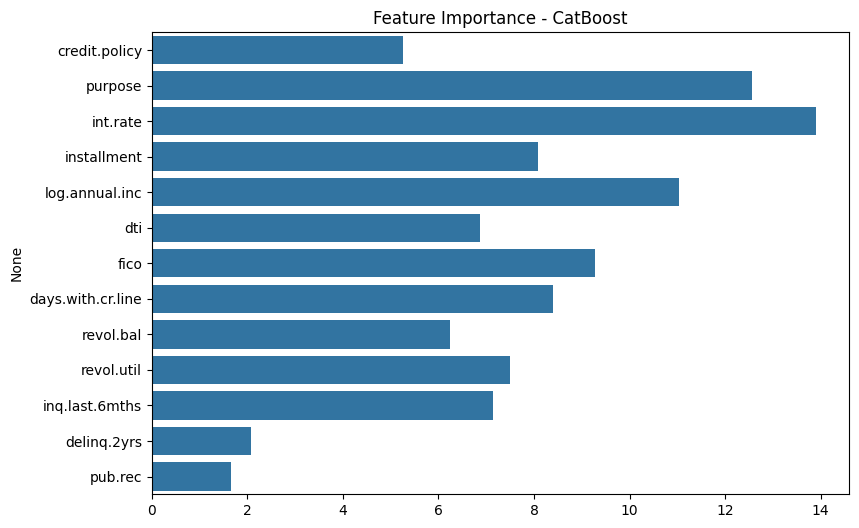

In [ ]:
feature_importance = model.get_feature_importance()
features = X.columns
plt.figure(figsize=(9,6))
sns.barplot(x=feature_importance, y=features)
plt.title("Feature Importance - CatBoost")
plt.show()

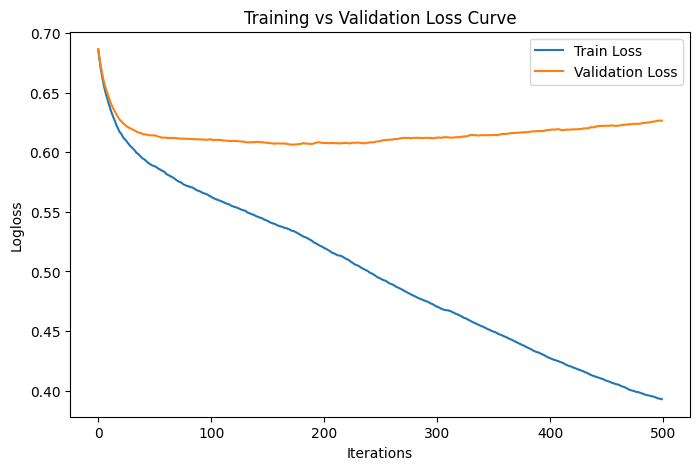

In [ ]:
evals_result = model.get_evals_result()
plt.figure(figsize=(8,5))
plt.plot(evals_result["learn"]["Logloss"], label="Train Loss")
plt.plot(evals_result["validation"]["Logloss"], label="Validation Loss")
plt.title("Training vs Validation Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Logloss")
plt.legend()
plt.show()